# Reddit dataset - basic metrics

Dataset = the two parquet files in `data/` (Reddit posts mentioning Trump, 2017-01..06 + 2018-01..06).
Nothing loads full data — sizes from stat(), rows from the parquet footer, category counts streamed per row-group (one column).

In [7]:
from collections import Counter
from pathlib import Path

import pandas as pd
import pyarrow.parquet as pq

DATA = next(p for p in (Path.cwd() / "data", Path.cwd().parent / "data") if p.is_dir())
FILES = {"submissions": DATA / "submissions_trump.parquet", "comments": DATA / "comments_trump.parquet"}
files = {k: pq.ParquetFile(p) for k, p in FILES.items()}

## size, rows, breakdown by type

In [8]:
overview = pd.DataFrame(
    {
        "size_MB": [FILES[k].stat().st_size / 1024**2 for k in files],
        "rows": [f.metadata.num_rows for f in files.values()],
    },
    index=list(files),
)
overview["rows_%"] = 100 * overview["rows"] / overview["rows"].sum()
overview.loc["TOTAL"] = overview.sum()
overview.round(1)

,size_MB,rows,rows_%
submissions,246.3,513848.0,10.0
comments,1319.2,4601620.0,90.0
TOTAL,1565.5,5115468.0,100.0


A plain read_parquet would need ~7.3 GB RAM for comments, ~8.5 GB for both files (measured below from a sample, extrapolated by row count).

In [ ]:
def est_pandas_gb(name, batch=20_000):
    f = files[name]
    # one batch from the start of every row group so different periods are sampled
    sample = pd.concat(
        next(f.iter_batches(batch_size=batch, row_groups=[i])).to_pandas()
        for i in range(f.metadata.num_row_groups)
    )
    per_row = sample.memory_usage(deep=True).sum() / len(sample)
    return {"sample_rows": len(sample), "bytes_per_row": per_row,
            "est_pandas_GB": per_row * f.metadata.num_rows / 1024**3}


est = pd.DataFrame({k: est_pandas_gb(k) for k in files}).T
est.loc["TOTAL", "est_pandas_GB"] = est["est_pandas_GB"].sum()
est.round(2)

,sample_rows,bytes_per_row,est_pandas_GB
submissions,20000.0,2434.96,1.17
comments,100000.0,1701.35,7.29
TOTAL,NaN,NaN,8.46


## counts per category

Two categorical columns present in both files: `subreddit` and `source_month`.
Counted row-group by row-group so the 1.4 GB comments file never lands in RAM at once.

In [10]:
def count_by(name, column):
    f = files[name]
    counts = Counter()
    for i in range(f.metadata.num_row_groups):
        counts.update(f.read_row_group(i, columns=[column])[column].to_pylist())
    return pd.Series(counts, name=name).sort_values(ascending=False)


by_month = pd.concat([count_by(k, "source_month") for k in files], axis=1).sort_index()
by_month

,submissions,comments
2017-01,39253,378728
2017-02,38588,321216
2017-03,33887,290558
2017-04,26421,203596
2017-05,35318,297488
2017-06,26793,264068
2018-01,28963,256804
2018-02,23134,196872
2018-03,26994,225168
2018-04,24080,216950


In [11]:
by_sub = pd.concat([count_by(k, "subreddit") for k in files], axis=1).fillna(0).astype(int)
print(f"distinct subreddits: {len(by_sub):,}")
by_sub.sort_values("comments", ascending=False).head(15)

distinct subreddits: 6


,submissions,comments
politics,410652,4161278
AskTrumpSupporters,29196,173211
Conservative,42467,102922
PoliticalDiscussion,7666,93890
democrats,17357,54506
Republican,6510,15813


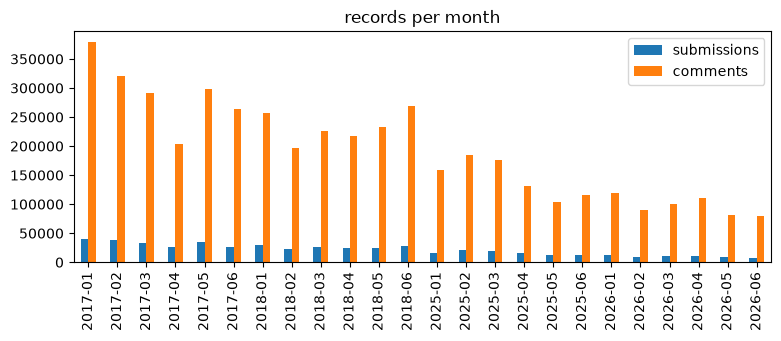

In [12]:
by_month.plot.bar(figsize=(9, 3), title="records per month");

## duplicates

Reddit `id` is unique per comment / per submission, so a repeated id = same record collected twice. Only the `id` column is read (~50 MB).

In [13]:
import pyarrow.compute as pc


def dup_check(name):
    ids = files[name].read(columns=["id"])["id"]
    valid = len(ids) - ids.null_count
    return {"rows": len(ids), "null_ids": ids.null_count, "duplicate_rows": valid - pc.count_distinct(ids).as_py()}


pd.DataFrame({k: dup_check(k) for k in files}).T

,rows,null_ids,duplicate_rows
submissions,513848,0,0
comments,4601620,0,0
